# Stage 1: Shortcut Candidate Extraction

**Objective:** Engineer 14 gender-associated linguistic features (mix of Hyland hedge lexicon, manual counts, and LIWC-22 categories). Test each as a standalone logistic-regression classifier (5-fold stratified CV, AUC). Features with AUC ≳ 0.60 are flagged as candidate shortcuts. Then use **mutual information (MI) decomposition** to distinguish genuine clinical signal from gender-confounded shortcuts.

| # | Feature | Gender Association | Measurement |
|---|---|---|---|
| 1 | Hedging / epistemic tentativeness | Feminine-coded | Hyland hedge lexicon count / tokens |
| 2 | First-person singular pronouns | Both (depression + feminine) | (I + me + my + myself + mine) / tokens |
| 3 | First-person plural pronouns | Masculine-coded (group identity) | (we + us + our) / tokens |
| 4 | Emotional / feeling language | Feminine-coded | LIWC `Affect` + `feeling` |
| 5 | Relational / social references | Feminine-coded | LIWC `Social`, `family`, `friend` |
| 6 | Certainty / assertive language | Masculine-coded | LIWC `certitude` |
| 7 | Negative emotion words | Both (depression + feminine) | LIWC `emo_neg` |
| 8 | Swear / taboo words | Masculine-coded | LIWC `swear` |
| 9 | Exclamation marks + intensifiers | Feminine-coded | Count of `!`, "so", "really", "very" |
| 10 | Question marks | Feminine-coded | Count of `?` / sentence count |
| 11 | Post length | Feminine-coded (longer posts) | Token count |
| 12 | Apology / self-blame language | Feminine-coded | "sorry", "my fault", "I should have" |
| 13 | Anger expression | Masculine-coded | LIWC `emo_anger` |
| 14 | Body / health references | Both (clinical + gendered) | LIWC `health`, `Physical` |

**Data:** 16,306 LIWC-22–annotated posts (all posts by 519 gender-identified users from 47,237 total)

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
# ── Load LIWC-annotated data ──────────────────────────────────────────────────
df = pd.read_csv('data/stage0/all-annotated.csv', low_memory=False)
df['text'] = df['text'].fillna('')

# Handle gender column name (propagated dataset uses gender_label)
GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'

# Coerce LIWC numeric columns
liwc_cols = ['WC', 'Affect', 'feeling', 'Social', 'family', 'friend',
             'certitude', 'emo_neg', 'swear', 'emo_anger', 'health', 'Physical']
for c in liwc_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

print(f"Loaded {len(df):,} rows  (gender column: '{GENDER_COL}')")
print(f"\nLabel distribution:\n{df['binary_label'].value_counts().to_string()}")
print(f"\nDataset distribution:\n{df['dataset'].value_counts().to_string()}")
print(f"\nGender distribution:\n{df[GENDER_COL].value_counts().to_string()}")
if 'gender_source' in df.columns:
    print(f"\nGender source:\n{df['gender_source'].value_counts().to_string()}")

Loaded 16,306 rows  (gender column: 'gender_label')

Label distribution:
binary_label
1    13993
0     2313

Dataset distribution:
dataset
umd        14672
cssrs       1285
mindset      349

Gender distribution:
gender_label
male            12077
female           3979
trans_female      189
trans_male         53
afab                3
amab                3
nonbinary           2

Gender source:
gender_source
propagated    15419
direct          887


In [43]:
# ── Hyland (2005) hedge lexicon + text-based helpers ─────────────────────────
# Canonical hedge list from Hyland's academic hedging taxonomy
HYLAND_HEDGES_SINGLE = {
    'about', 'almost', 'apparently', 'approximately', 'argue', 'argued', 'argues',
    'around', 'assume', 'assumed', 'assumes', 'broadly', 'certain', 'claim',
    'claimed', 'claims', 'conceivable', 'conceivably', 'could', 'doubt',
    'doubtful', 'essentially', 'estimate', 'estimated', 'fairly', 'feel',
    'feels', 'felt', 'frequently', 'generally', 'guess', 'hypothesize',
    'hypothesized', 'hypothesizes', 'implication', 'imply', 'indicate',
    'indicated', 'indicates', 'largely', 'likely', 'mainly', 'may', 'maybe',
    'might', 'mostly', 'normally', 'occasionally', 'often', 'partly',
    'perhaps', 'plausible', 'plausibly', 'possible', 'possibly', 'postulate',
    'postulated', 'postulates', 'presumably', 'probable', 'probably', 'quite',
    'rather', 'relatively', 'roughly', 'seem', 'seemed', 'seemingly', 'seems',
    'should', 'sometimes', 'somewhat', 'suggest', 'suggested', 'suggests',
    'suppose', 'supposed', 'supposes', 'suspect', 'suspected', 'suspects',
    'tend', 'tended', 'tends', 'think', 'thinks', 'thought', 'typical',
    'typically', 'uncertain', 'uncertainly', 'unclear', 'unlikely', 'usually',
    'wonder', 'wondered', 'wonders', 'would',
}
HYLAND_HEDGES_MULTI = [
    'kind of', 'sort of', 'more or less', 'to some extent',
    'in general', 'in most cases', 'on the whole', 'for the most part',
    'i think', 'i believe', 'i feel', 'i guess', 'i suppose',
    'it seems', 'it appears', 'in my opinion', 'to my knowledge',
]

FP_SINGULAR = {'i', 'me', 'my', 'myself', 'mine'}
FP_PLURAL   = {'we', 'us', 'our', 'ours', 'ourselves'}

INTENSIFIERS = {'so', 'really', 'very'}

APOLOGY_PHRASES = [
    'sorry', 'i\'m sorry', 'im sorry', 'my fault', 'my bad',
    'i should have', 'i shouldn\'t have', 'i shouldnt have',
    'i apologize', 'i apologise', 'forgive me', 'pardon me',
    'it\'s my fault', 'its my fault', 'i was wrong',
]

def tokenize(text):
    """Simple whitespace + punctuation-aware tokenizer."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def count_sentences(text):
    """Approximate sentence count via terminal punctuation."""
    sents = re.split(r'[.!?]+', text.strip())
    return max(len([s for s in sents if s.strip()]), 1)

print(f"Hyland single-word hedges: {len(HYLAND_HEDGES_SINGLE)}")
print(f"Hyland multi-word hedges:  {len(HYLAND_HEDGES_MULTI)}")
print(f"Apology phrases:           {len(APOLOGY_PHRASES)}")

Hyland single-word hedges: 98
Hyland multi-word hedges:  17
Apology phrases:           15


In [44]:
# ── Compute all 14 features ──────────────────────────────────────────────────
# We define a master table so every downstream cell can reference it consistently.

FEATURES = {
    # name                    : (gender_assoc,           source)
    'hedge_density'           : ('Feminine-coded',       'text'),
    'fp_singular'             : ('Both (depr + fem)',    'text'),
    'fp_plural'               : ('Masculine-coded',      'text'),
    'emotional_feeling'       : ('Feminine-coded',       'liwc'),
    'social_relational'       : ('Feminine-coded',       'liwc'),
    'certainty'               : ('Masculine-coded',      'liwc'),
    'negative_emotion'        : ('Both (depr + fem)',    'liwc'),
    'swear_words'             : ('Masculine-coded',      'liwc'),
    'excl_intensifiers'       : ('Feminine-coded',       'text'),
    'question_density'        : ('Feminine-coded',       'text'),
    'post_length'             : ('Feminine-coded',       'liwc'),
    'apology_selfblame'       : ('Feminine-coded',       'text'),
    'anger'                   : ('Masculine-coded',      'liwc'),
    'body_health'             : ('Both (clin + gen)',    'liwc'),
}
FEATURE_NAMES = list(FEATURES.keys())

def compute_features(row):
    text = str(row['text'])
    text_lower = text.lower()
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    n_sent = count_sentences(text)

    # 1. Hedging — Hyland lexicon
    hedge_count = sum(1 for t in tokens if t in HYLAND_HEDGES_SINGLE)
    for phrase in HYLAND_HEDGES_MULTI:
        hedge_count += text_lower.count(phrase)
    hedge_density = hedge_count / n_tok

    # 2. First-person singular
    fp_sing = sum(1 for t in tokens if t in FP_SINGULAR) / n_tok

    # 3. First-person plural
    fp_plur = sum(1 for t in tokens if t in FP_PLURAL) / n_tok

    # 4. Emotional / feeling language — LIWC Affect + feeling
    emotional_feeling = np.nanmean([row.get('Affect', 0), row.get('feeling', 0)])

    # 5. Relational / social — LIWC Social, family, friend
    social_relational = np.nanmean([row.get('Social', 0), row.get('family', 0), row.get('friend', 0)])

    # 6. Certainty — LIWC certitude
    certainty = row.get('certitude', 0) or 0

    # 7. Negative emotion — LIWC emo_neg
    negative_emotion = row.get('emo_neg', 0) or 0

    # 8. Swear / taboo — LIWC swear
    swear_words = row.get('swear', 0) or 0

    # 9. Exclamation marks + intensifiers
    excl_count = text.count('!')
    intens_count = sum(1 for t in tokens if t in INTENSIFIERS)
    excl_intensifiers = (excl_count + intens_count) / n_tok

    # 10. Question marks / sentence count
    question_density = text.count('?') / n_sent

    # 11. Post length — LIWC WC
    post_length = row.get('WC', n_tok) or n_tok

    # 12. Apology / self-blame
    apology_count = sum(text_lower.count(p) for p in APOLOGY_PHRASES)
    apology_selfblame = apology_count / n_tok

    # 13. Anger — LIWC emo_anger
    anger = row.get('emo_anger', 0) or 0

    # 14. Body / health — LIWC health + Physical
    body_health = np.nanmean([row.get('health', 0), row.get('Physical', 0)])

    return pd.Series({
        'hedge_density': hedge_density,
        'fp_singular': fp_sing,
        'fp_plural': fp_plur,
        'emotional_feeling': emotional_feeling,
        'social_relational': social_relational,
        'certainty': certainty,
        'negative_emotion': negative_emotion,
        'swear_words': swear_words,
        'excl_intensifiers': excl_intensifiers,
        'question_density': question_density,
        'post_length': post_length,
        'apology_selfblame': apology_selfblame,
        'anger': anger,
        'body_health': body_health,
    })

print("Computing 14 features …")
feat_df = df.apply(compute_features, axis=1)
for col in FEATURE_NAMES:
    df[col] = feat_df[col].astype(float)

print("Done.\n")
df[FEATURE_NAMES].describe().round(4)

Computing 14 features …
Done.



,hedge_density,fp_singular,fp_plural,emotional_feeling,social_relational,certainty,negative_emotion,swear_words,excl_intensifiers,question_density,post_length,apology_selfblame,anger,body_health
count,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000,16306.0000
mean,0.0254,0.0508,0.0039,2.9573,3.8603,0.6189,0.7488,0.3198,0.0147,0.2319,134.7998,0.0007,0.1571,1.2667
std,0.0283,0.0435,0.0119,2.6772,2.6911,1.3681,1.8298,1.4242,0.0342,0.2769,242.7435,0.0076,0.7542,2.2276
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
25%,0.0000,0.0139,0.0000,1.3500,1.9708,0.0000,0.0000,0.0000,0.0000,0.0000,37.0000,0.0000,0.0000,0.0000
50%,0.0204,0.0455,0.0000,2.5700,3.4500,0.0000,0.0000,0.0000,0.0063,0.1429,70.0000,0.0000,0.0000,0.3000
75%,0.0380,0.0789,0.0000,4.0000,5.2758,0.8100,0.9200,0.0000,0.0192,0.4000,143.0000,0.0000,0.0000,1.6900
max,0.5000,0.5000,0.3333,50.0000,33.3333,33.3300,100.0000,50.0000,1.5000,6.0000,7083.0000,0.6667,33.3300,40.7400


In [45]:
# ── Single-feature AUC evaluation ─────────────────────────────────────────────
AUC_THRESHOLD = 0.60

def evaluate_feature(data, feature, target='binary_label', n_splits=5):
    """5-fold stratified CV logistic-regression AUC for one feature."""
    X = data[[feature]].values.astype(float)
    y = data[target].values.astype(float)
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    X, y = X[mask], y[mask]
    if len(np.unique(y)) < 2 or len(y) < n_splits * 2:
        return None
    X = StandardScaler().fit_transform(X)
    clf = LogisticRegression(max_iter=1000, random_state=42)
    cv  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X, y, cv=cv, scoring='roc_auc')
    return {'feature': feature, 'mean_auc': aucs.mean(), 'std_auc': aucs.std(),
            'min_auc': aucs.min(), 'max_auc': aucs.max()}

results = []
for feat in FEATURE_NAMES:
    res = evaluate_feature(df, feat)
    if res:
        gender, source = FEATURES[feat]
        res['gender_association'] = gender
        res['source'] = source
        results.append(res)

results_df = pd.DataFrame(results).sort_values('mean_auc', ascending=False).reset_index(drop=True)
results_df['is_shortcut'] = results_df['mean_auc'] >= AUC_THRESHOLD

n_short = results_df['is_shortcut'].sum()
print(f"Tested {len(results_df)} features  →  {n_short} with AUC ≥ {AUC_THRESHOLD}\n")
results_df[['feature', 'gender_association', 'source', 'mean_auc', 'std_auc', 'is_shortcut']]

Tested 14 features  →  0 with AUC ≥ 0.6



,feature,gender_association,source,mean_auc,std_auc,is_shortcut
0,fp_singular,Both (depr + fem),text,0.5467,0.0126,False
1,negative_emotion,Both (depr + fem),liwc,0.5444,0.0099,False
2,social_relational,Feminine-coded,liwc,0.5319,0.0096,False
3,anger,Masculine-coded,liwc,0.5202,0.0037,False
4,body_health,Both (clin + gen),liwc,0.5177,0.0109,False
5,emotional_feeling,Feminine-coded,liwc,0.5139,0.0094,False
6,post_length,Feminine-coded,liwc,0.5131,0.0079,False
7,fp_plural,Masculine-coded,text,0.5090,0.0057,False
8,hedge_density,Feminine-coded,text,0.5081,0.0192,False
9,excl_intensifiers,Feminine-coded,text,0.5060,0.0158,False


In [46]:
# ── Per-dataset breakdown ─────────────────────────────────────────────────────
per_ds = []
for ds in sorted(df['dataset'].unique()):
    sub = df[df['dataset'] == ds]
    if sub['binary_label'].nunique() < 2:
        continue
    for feat in FEATURE_NAMES:
        res = evaluate_feature(sub, feat)
        if res:
            res['dataset'] = ds
            per_ds.append(res)

per_ds_df = pd.DataFrame(per_ds)
pivot = per_ds_df.pivot(index='feature', columns='dataset', values='mean_auc').round(3)
# Reorder by overall AUC
pivot['overall'] = results_df.set_index('feature').reindex(pivot.index)['mean_auc']
pivot = pivot.sort_values('overall', ascending=False)

print("AUC per dataset (all 14 features):")
pivot

AUC per dataset (all 14 features):


dataset,cssrs,mindset,umd,overall
feature,,,,
fp_singular,0.6230,0.7570,0.5330,0.5467
negative_emotion,0.5710,0.6380,0.5420,0.5444
social_relational,0.6250,0.5910,0.5170,0.5319
anger,0.5420,0.5700,0.5170,0.5202
body_health,0.5740,0.5900,0.5110,0.5177
emotional_feeling,0.4710,0.5330,0.5210,0.5139
post_length,0.4910,0.5170,0.5080,0.5131
fp_plural,0.4840,0.5960,0.5120,0.5090
hedge_density,0.5550,0.3740,0.4980,0.5081


In [49]:
# ================================================================
# MUTUAL INFORMATION DECOMPOSITION — Gender Shortcut Detection
# ================================================================
# For each feature f, compute:
#   I(f; label)         — unconditional MI with mental-health label
#   I(f; gender)        — how strongly the feature correlates with gender
#   I(f; label | gender)— MI with label AFTER conditioning on gender
#
# A feature is a gender shortcut candidate when:
#   • I(f; gender) is high   (feature is gender-correlated)
#   • I(f; label|gender) drops substantially vs I(f; label)
#     (predictive power is partly explained by gender, not clinical content)

from sklearn.feature_selection import mutual_info_classif

# Restrict to male / female for binary MI (largest groups, avoids MI noise)
mi_data = df[df[GENDER_COL].isin(['male', 'female'])].copy()
mi_data['gender_bin'] = (mi_data[GENDER_COL] == 'female').astype(int)

X_feat   = mi_data[FEATURE_NAMES].fillna(0).values.astype(float)
y_label  = mi_data['binary_label'].values.astype(int)
y_gender = mi_data['gender_bin'].values.astype(int)

print(f"MI analysis on {len(mi_data):,} rows  (male: {(y_gender==0).sum():,}, female: {(y_gender==1).sum():,})")

# ── I(f; label) — unconditional ──────────────────────────────────────────────
mi_label = mutual_info_classif(
    X_feat, y_label, discrete_features=False, n_neighbors=5, random_state=42)

# ── I(f; gender) ─────────────────────────────────────────────────────────────
mi_gender = mutual_info_classif(
    X_feat, y_gender, discrete_features=False, n_neighbors=5, random_state=42)

# ── I(f; label | gender) — conditional MI via stratification ─────────────────
#   I(f; label | gender) = Σ_g P(g) · I(f; label)_{within gender=g}
mi_cond = np.zeros(len(FEATURE_NAMES))
for g_val in [0, 1]:
    mask = y_gender == g_val
    p_g  = mask.mean()
    n_g  = mask.sum()
    if n_g >= 30:  # need enough samples for stable MI estimate
        mi_g = mutual_info_classif(
            X_feat[mask], y_label[mask],
            discrete_features=False, n_neighbors=5, random_state=42)
        mi_cond += p_g * mi_g

# ── Build results table ──────────────────────────────────────────────────────
mi_df = pd.DataFrame({
    'feature':            FEATURE_NAMES,
    'gender_assoc':       [FEATURES[f][0] for f in FEATURE_NAMES],
    'I(f;label)':         mi_label,
    'I(f;gender)':        mi_gender,
    'I(f;label|gender)':  mi_cond,
})

# MI drop: how much label-MI is lost after accounting for gender
# Positive = gender confounds (part of signal was gender-mediated)
# Negative = gender suppresses (gender was masking some signal)
mi_df['MI_drop'] = mi_df['I(f;label)'] - mi_df['I(f;label|gender)']

# Percentage drop — only meaningful when I(f;label) is non-negligible
# Use absolute drop in nats as primary metric; % as secondary for I(f;label) > 0.001
MIN_MI = 0.001  # below this, MI estimates are noise-dominated
mi_df['MI_drop_pct'] = np.where(
    mi_df['I(f;label)'] >= MIN_MI,
    (mi_df['MI_drop'] / mi_df['I(f;label)']) * 100,
    np.nan  # undefined when unconditional MI is near zero
)

# Flag: feature is gender-correlated AND conditioning on gender substantially
# reduces its MI with label (>20% drop AND above-median gender correlation)
median_mi_g = mi_df['I(f;gender)'].median()
mi_df['shortcut_flag'] = (
    (mi_df['I(f;gender)'] > median_mi_g) &
    (mi_df['MI_drop_pct'].fillna(0) > 20)
)

mi_df = mi_df.sort_values('I(f;gender)', ascending=False).reset_index(drop=True)

n_flagged = mi_df['shortcut_flag'].sum()
print(f"\nMedian I(f;gender) = {median_mi_g:.4f}")
print(f"Gender shortcut candidates (I(f;gender) > median AND MI drop > 20%): {n_flagged}\n")

pd.set_option('display.float_format', '{:.4f}'.format)
mi_df

MI analysis on 16,056 rows  (male: 12,077, female: 3,979)

Median I(f;gender) = 0.0040
Gender shortcut candidates (I(f;gender) > median AND MI drop > 20%): 3



,feature,gender_assoc,I(f;label),I(f;gender),I(f;label|gender),MI_drop,MI_drop_pct,shortcut_flag
0,fp_singular,Both (depr + fem),0.0049,0.0065,0.0047,0.0001,2.9456,False
1,swear_words,Masculine-coded,0.0000,0.0062,0.0013,-0.0013,NaN,False
2,question_density,Feminine-coded,0.0020,0.0060,0.0011,0.0009,43.0137,True
3,body_health,Both (clin + gen),0.0000,0.0060,0.0021,-0.0021,NaN,False
4,negative_emotion,Both (depr + fem),0.0056,0.0059,0.0030,0.0026,46.9340,True
5,certainty,Masculine-coded,0.0036,0.0044,0.0021,0.0015,42.4938,True
6,excl_intensifiers,Feminine-coded,0.0024,0.0043,0.0033,-0.0008,-34.0175,False
7,social_relational,Feminine-coded,0.0036,0.0037,0.0026,0.0010,28.4463,False
8,post_length,Feminine-coded,0.0002,0.0030,0.0029,-0.0027,NaN,False
9,fp_plural,Masculine-coded,0.0000,0.0029,0.0016,-0.0016,NaN,False


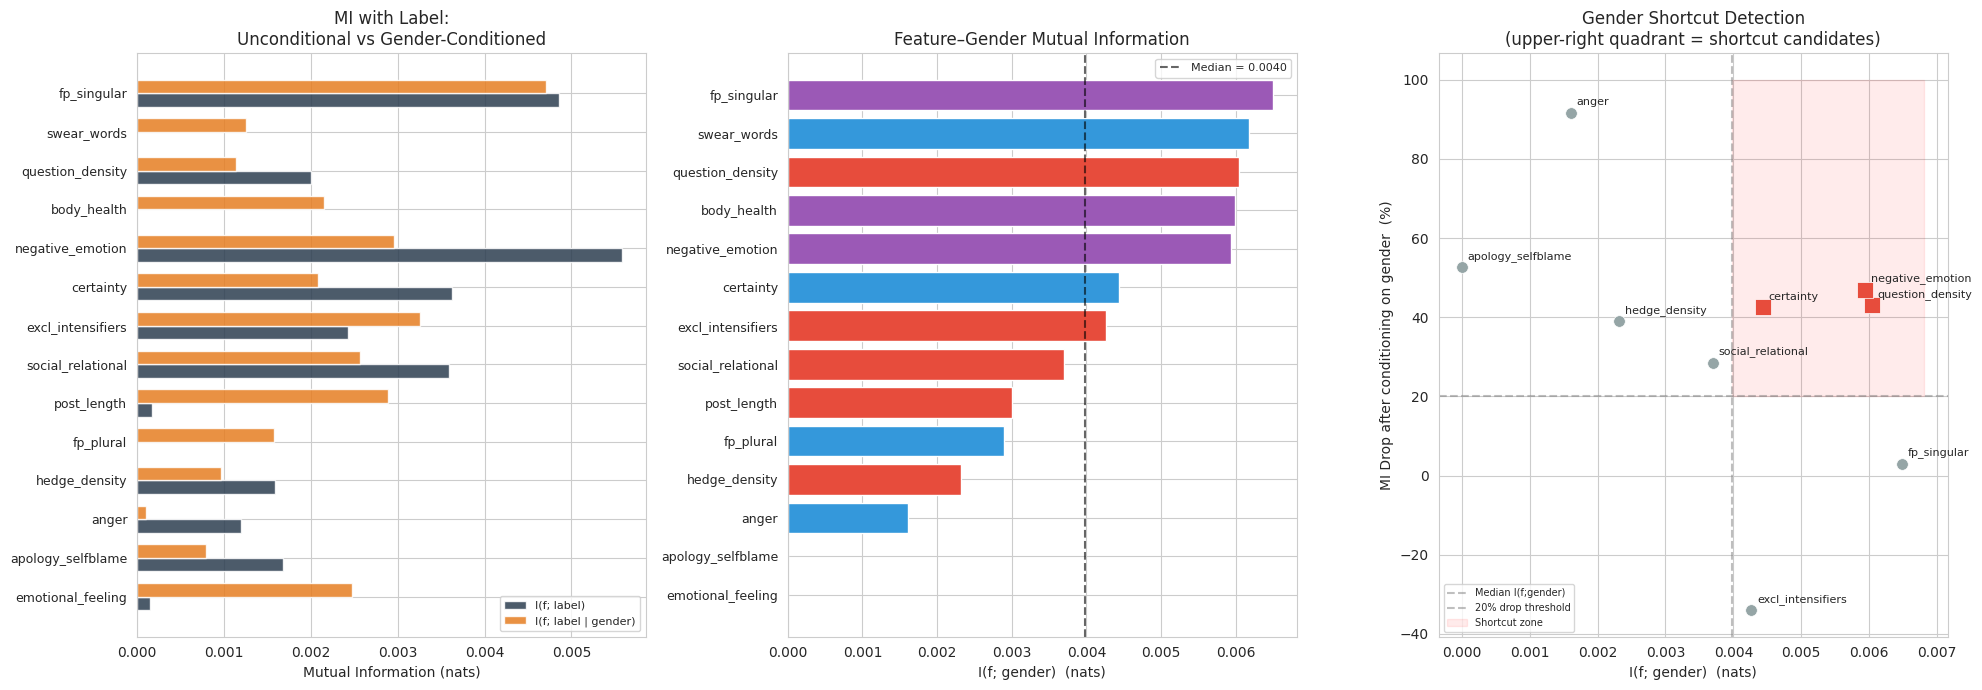

Saved → data/stage1/mi_shortcut_analysis.png


In [50]:
# ── MI Visualization ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

mi_sorted = mi_df.sort_values('I(f;gender)', ascending=True)

# ── (A) I(f;label) vs I(f;label|gender) — grouped bars ──────────────────────
y_pos = np.arange(len(mi_sorted))
bar_h = 0.35

axes[0].barh(y_pos - bar_h/2, mi_sorted['I(f;label)'], bar_h,
             label='I(f; label)', color='#2c3e50', alpha=0.85)
axes[0].barh(y_pos + bar_h/2, mi_sorted['I(f;label|gender)'], bar_h,
             label='I(f; label | gender)', color='#e67e22', alpha=0.85)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(mi_sorted['feature'], fontsize=9)
axes[0].set_xlabel('Mutual Information (nats)')
axes[0].set_title('MI with Label:\nUnconditional vs Gender-Conditioned')
axes[0].legend(fontsize=8, loc='lower right')

# ── (B) I(f;gender) — gender correlation ranking ────────────────────────────
palette = {'Feminine-coded': '#e74c3c', 'Masculine-coded': '#3498db',
           'Both (depr + fem)': '#9b59b6', 'Both (clin + gen)': '#9b59b6'}
colors = [palette.get(FEATURES[f][0], '#95a5a6') for f in mi_sorted['feature']]

axes[1].barh(y_pos, mi_sorted['I(f;gender)'], color=colors, edgecolor='white')
axes[1].axvline(median_mi_g, color='black', linestyle='--', alpha=0.6,
                label=f'Median = {median_mi_g:.4f}')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(mi_sorted['feature'], fontsize=9)
axes[1].set_xlabel('I(f; gender)  (nats)')
axes[1].set_title('Feature–Gender Mutual Information')
axes[1].legend(fontsize=8)

# ── (C) Scatter: I(f;gender) vs MI drop % — shortcut quadrant ───────────────
# Only plot features with meaningful MI_drop_pct (I(f;label) >= MIN_MI)
mi_plot = mi_df.dropna(subset=['MI_drop_pct']).copy()

for _, row in mi_plot.iterrows():
    color = '#e74c3c' if row['shortcut_flag'] else '#95a5a6'
    marker = 's' if row['shortcut_flag'] else 'o'
    size = 120 if row['shortcut_flag'] else 70
    axes[2].scatter(row['I(f;gender)'], row['MI_drop_pct'],
                    c=color, marker=marker, s=size, edgecolors='white',
                    linewidth=0.5, zorder=3)
    axes[2].annotate(row['feature'], (row['I(f;gender)'], row['MI_drop_pct']),
                     fontsize=8, ha='left', va='bottom',
                     xytext=(4, 4), textcoords='offset points')

axes[2].axvline(median_mi_g, color='grey', linestyle='--', alpha=0.5,
                label=f'Median I(f;gender)')
axes[2].axhline(20, color='grey', linestyle='--', alpha=0.5, label='20% drop threshold')
axes[2].set_xlabel('I(f; gender)  (nats)')
axes[2].set_ylabel('MI Drop after conditioning on gender  (%)')
axes[2].set_title('Gender Shortcut Detection\n(upper-right quadrant = shortcut candidates)')

# Shade the shortcut quadrant
xlim = axes[2].get_xlim()
ylim = axes[2].get_ylim()
axes[2].fill_between([median_mi_g, xlim[1]], 20, max(ylim[1], 100),
                     alpha=0.08, color='red', label='Shortcut zone')
axes[2].legend(fontsize=7, loc='lower left')

plt.tight_layout()
plt.savefig('data/stage1/mi_shortcut_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage1/mi_shortcut_analysis.png")

In [51]:
# ── Combined model (all 14 features) ─────────────────────────────────────────
X_all = df[FEATURE_NAMES].fillna(0).values.astype(float)
y_all = df['binary_label'].values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

clf = LogisticRegression(max_iter=1000, random_state=42)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs = cross_val_score(clf, X_scaled, y_all, cv=cv, scoring='roc_auc')

print(f"Combined model (14 features)")
print(f"  AUC = {aucs.mean():.3f} ± {aucs.std():.3f}")
print(f"  Folds: {', '.join(f'{a:.3f}' for a in aucs)}")

# Coefficient analysis
clf.fit(X_scaled, y_all)
coef_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'gender_association': [FEATURES[f][0] for f in FEATURE_NAMES],
    'coefficient': clf.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\nLogistic regression coefficients (combined model):")
coef_df

Combined model (14 features)
  AUC = 0.568 ± 0.003
  Folds: 0.567, 0.564, 0.574, 0.569, 0.564

Logistic regression coefficients (combined model):


,feature,gender_association,coefficient
6,negative_emotion,Both (depr + fem),0.2197
1,fp_singular,Both (depr + fem),0.1659
11,apology_selfblame,Feminine-coded,-0.0757
4,social_relational,Feminine-coded,-0.0720
0,hedge_density,Feminine-coded,-0.0578
9,question_density,Feminine-coded,0.0483
3,emotional_feeling,Feminine-coded,0.0262
10,post_length,Feminine-coded,0.0247
13,body_health,Both (clin + gen),0.0217
7,swear_words,Masculine-coded,-0.0193


In [52]:
# ── Gender-stratified analysis ────────────────────────────────────────────────
# Compare feature means between male vs female posts to validate gender coding
male_df   = df[df[GENDER_COL] == 'male']
female_df = df[df[GENDER_COL] == 'female']

gender_comp = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'gender_association': [FEATURES[f][0] for f in FEATURE_NAMES],
    'mean_male': [male_df[f].mean() for f in FEATURE_NAMES],
    'mean_female': [female_df[f].mean() for f in FEATURE_NAMES],
})
gender_comp['diff (F−M)'] = gender_comp['mean_female'] - gender_comp['mean_male']
gender_comp['direction'] = gender_comp['diff (F−M)'].apply(
    lambda x: '↑ Female' if x > 0.001 else ('↑ Male' if x < -0.001 else '≈ Equal'))

print(f"Feature means: male (n={len(male_df):,}) vs female (n={len(female_df):,})")
gender_comp

Feature means: male (n=12,077) vs female (n=3,979)


,feature,gender_association,mean_male,mean_female,diff (F−M),direction
0,hedge_density,Feminine-coded,0.0249,0.0267,0.0018,↑ Female
1,fp_singular,Both (depr + fem),0.0486,0.0562,0.0076,↑ Female
2,fp_plural,Masculine-coded,0.0041,0.0035,-0.0006,≈ Equal
3,emotional_feeling,Feminine-coded,2.8724,3.2155,0.3432,↑ Female
4,social_relational,Feminine-coded,3.7928,4.0507,0.2579,↑ Female
5,certainty,Masculine-coded,0.5890,0.6813,0.0923,↑ Female
6,negative_emotion,Both (depr + fem),0.6637,0.9904,0.3267,↑ Female
7,swear_words,Masculine-coded,0.3252,0.3007,-0.0245,↑ Male
8,excl_intensifiers,Feminine-coded,0.0134,0.0182,0.0048,↑ Female
9,question_density,Feminine-coded,0.2429,0.2057,-0.0372,↑ Male


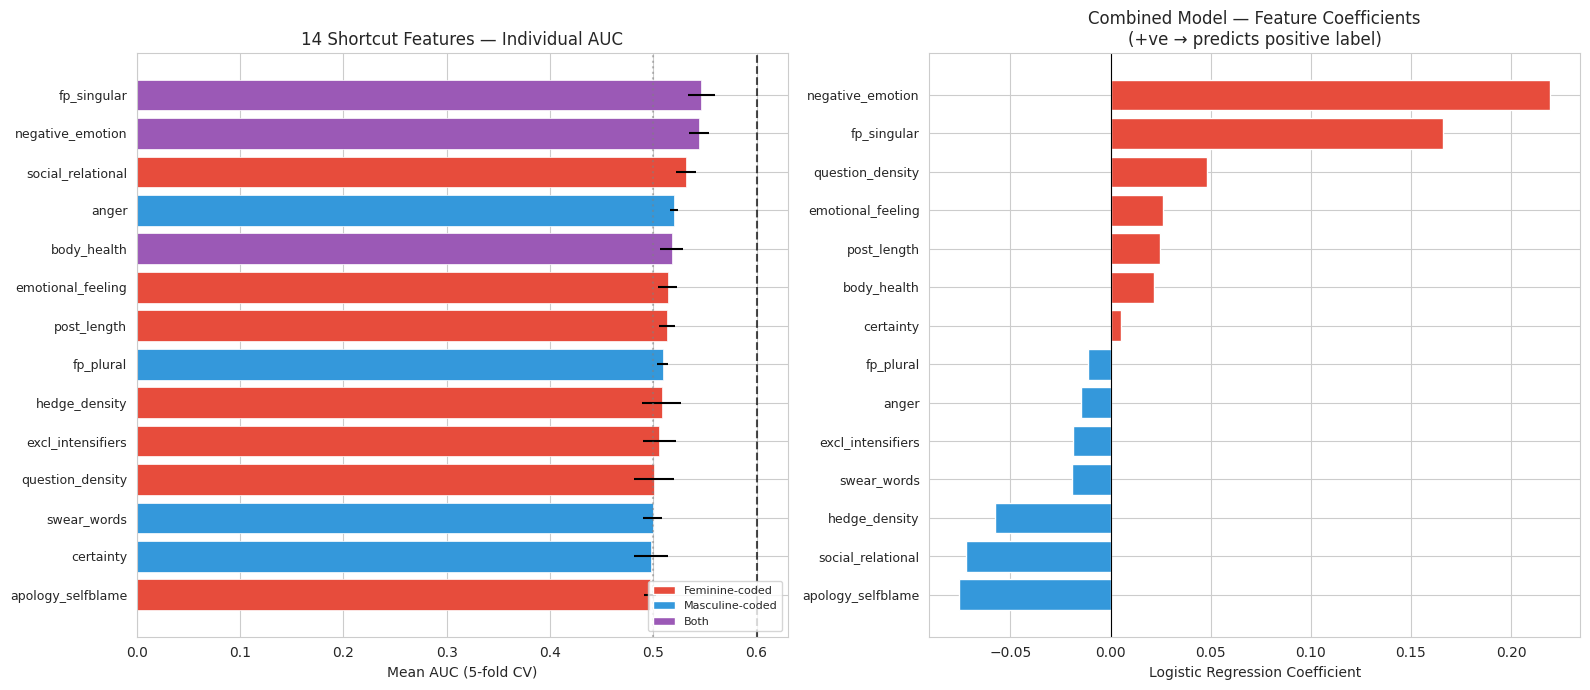

Saved → data/stage1/shortcut_features_14.png


In [53]:
# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# (A) Individual feature AUCs with gender color coding
r = results_df.sort_values('mean_auc', ascending=True).copy()
palette = {'Feminine-coded': '#e74c3c', 'Masculine-coded': '#3498db',
           'Both (depr + fem)': '#9b59b6', 'Both (clin + gen)': '#9b59b6'}
colors = [palette.get(FEATURES[f][0], '#95a5a6') for f in r['feature']]

axes[0].barh(range(len(r)), r['mean_auc'], xerr=r['std_auc'],
             color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(r)))
axes[0].set_yticklabels(r['feature'], fontsize=9)
axes[0].axvline(AUC_THRESHOLD, color='black', linestyle='--', alpha=0.7, label=f'Threshold = {AUC_THRESHOLD}')
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Chance = 0.5')
axes[0].set_xlabel('Mean AUC (5-fold CV)')
axes[0].set_title('14 Shortcut Features — Individual AUC')
axes[0].legend(loc='lower right', fontsize=8)

# Custom legend for gender
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Feminine-coded'),
                   Patch(facecolor='#3498db', label='Masculine-coded'),
                   Patch(facecolor='#9b59b6', label='Both')]
axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# (B) Coefficient magnitudes (combined model)
c = coef_df.copy().sort_values('coefficient')
colors_c = ['#e74c3c' if v > 0 else '#3498db' for v in c['coefficient']]
axes[1].barh(range(len(c)), c['coefficient'], color=colors_c, edgecolor='white')
axes[1].set_yticks(range(len(c)))
axes[1].set_yticklabels(c['feature'], fontsize=9)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Combined Model — Feature Coefficients\n(+ve → predicts positive label)')

plt.tight_layout()
plt.savefig('data/stage1/shortcut_features_14.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage1/shortcut_features_14.png")

In [54]:
# ── Save results ──────────────────────────────────────────────────────────────
results_df.to_csv('data/stage1/shortcut_14_feature_aucs.csv', index=False)
mi_df.to_csv('data/stage1/shortcut_14_mi_analysis.csv', index=False)
df.to_pickle('data/stage1/features_14_extracted.pkl')

print("=" * 60)
print("STAGE 1 SUMMARY")
print("=" * 60)

shortcut_features = results_df[results_df['is_shortcut']]['feature'].tolist()
print(f"\n(A) AUC-based shortcuts (AUC ≥ {AUC_THRESHOLD}):")
for f in shortcut_features:
    row = results_df[results_df['feature'] == f].iloc[0]
    print(f"  • {f:25s}  AUC = {row['mean_auc']:.3f} ± {row['std_auc']:.3f}  [{row['gender_association']}]")
if not shortcut_features:
    print(f"  (none exceed {AUC_THRESHOLD}; consider lowering threshold)")

mi_shortcuts = mi_df[mi_df['shortcut_flag']]['feature'].tolist()
print(f"\n(B) MI-based gender shortcuts (I(f;gender)>median AND MI drop>20%):")
for f in mi_shortcuts:
    row = mi_df[mi_df['feature'] == f].iloc[0]
    print(f"  • {f:25s}  I(f;gender)={row['I(f;gender)']:.4f}  "
          f"MI drop={row['MI_drop_pct']:.1f}%  [{row['gender_assoc']}]")
if not mi_shortcuts:
    print(f"  (no features meet both criteria)")

print(f"\nCombined 14-feature AUC = {aucs.mean():.3f} ± {aucs.std():.3f}")
print(f"\nSaved:")
print(f"  → data/stage1/shortcut_14_feature_aucs.csv")
print(f"  → data/stage1/shortcut_14_mi_analysis.csv")
print(f"  → data/stage1/features_14_extracted.pkl")
print(f"  → data/stage1/shortcut_features_14.png")
print(f"  → data/stage1/mi_shortcut_analysis.png")

STAGE 1 SUMMARY

(A) AUC-based shortcuts (AUC ≥ 0.6):
  (none exceed 0.6; consider lowering threshold)

(B) MI-based gender shortcuts (I(f;gender)>median AND MI drop>20%):
  • question_density           I(f;gender)=0.0060  MI drop=43.0%  [Feminine-coded]
  • negative_emotion           I(f;gender)=0.0059  MI drop=46.9%  [Both (depr + fem)]
  • certainty                  I(f;gender)=0.0044  MI drop=42.5%  [Masculine-coded]

Combined 14-feature AUC = 0.568 ± 0.003

Saved:
  → data/stage1/shortcut_14_feature_aucs.csv
  → data/stage1/shortcut_14_mi_analysis.csv
  → data/stage1/features_14_extracted.pkl
  → data/stage1/shortcut_features_14.png
  → data/stage1/mi_shortcut_analysis.png
